In [1]:
# Importing the dependent modules
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [18]:
# Loading the dataset to a pandas dataframe
dataset = pd.read_csv("Position_Salaries.csv")
# ALl positions are unique here that is same as level so no need position column
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:,-1].values

In [19]:
dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [15]:
dataset.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [22]:
# Training the Liner Regression model with whole dataset
from sklearn.linear_model import LinearRegression
lin_regressor = LinearRegression()
lin_regressor.fit(X, y)

LinearRegression()

In [23]:
# Score of the model
lin_regressor.score(X, y)

0.6690412331929895

In [25]:
# Extract polynomial features
from sklearn.preprocessing import PolynomialFeatures

poly_reg = PolynomialFeatures(degree=2) # degree => n = 2 (2 extra features)
X_poly = poly_reg.fit_transform(X)
X_poly

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

In [26]:
# Traingin Polynomial Regression with whole dataset
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

LinearRegression()

In [27]:
# score of the polynomial model
lin_reg_2.score(X_poly, y)

0.9162082221443942

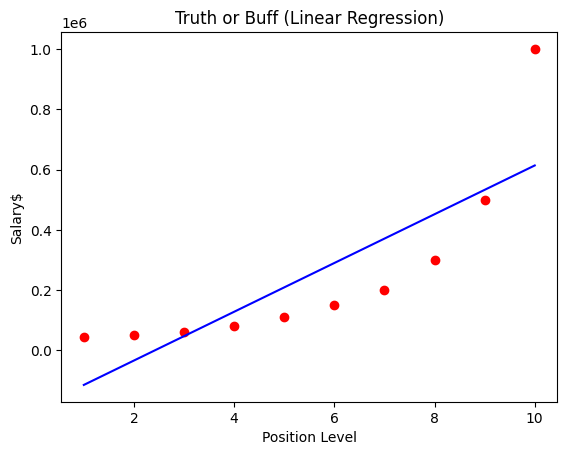

In [30]:
# Visualizing the Linear Regression Result
plt.scatter(X, y, color="red") # Actual salaries
plt.plot(X, lin_regressor.predict(X), color="blue") # predicted salaries
plt.title("Truth or Buff (Linear Regression)")
plt.xlabel("Position Level")
plt.ylabel("Salary$")
plt.show()

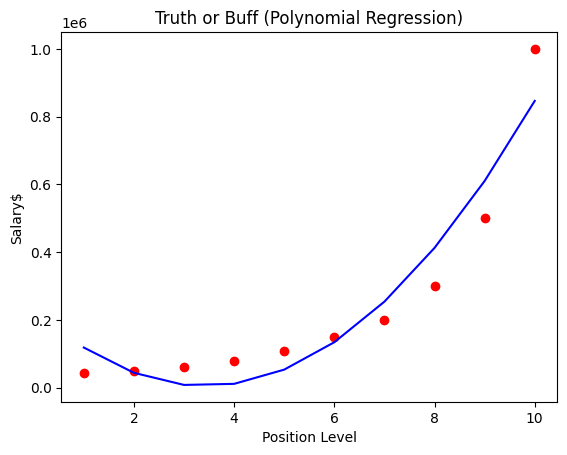

In [32]:
# Visualizing the Polynomial Regression Result
plt.scatter(X, y, color="red") # Actual salaries
plt.plot(X, lin_reg_2.predict(X_poly), color="blue") # predicted salaries
plt.title("Truth or Buff (Polynomial Regression)")
plt.xlabel("Position Level")
plt.ylabel("Salary$")
plt.show()

/tmp/ipykernel_5764/3429484109.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


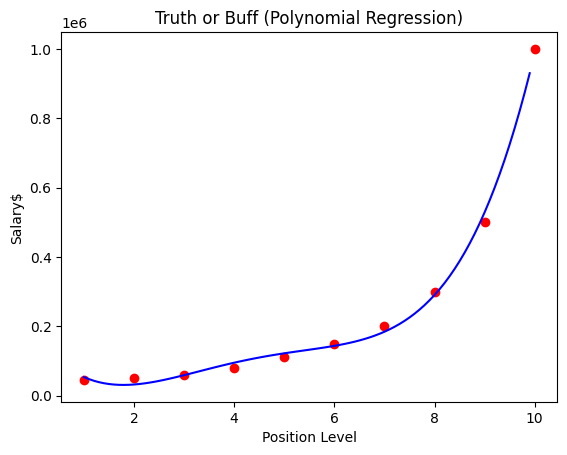

In [36]:
# Visualizing the Polynomial Regreesion Results (for Higher Resolution and smoother Curve) with degree 4
poly_reg = PolynomialFeatures(degree=4) # degree => n = 4 (4 extra features)
X_poly = poly_reg.fit_transform(X)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape(len(X_grid), 1)
plt.scatter(X, y, color="red") # Actual salaries
plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color="blue") # predicted salaries
plt.title("Truth or Buff (Polynomial Regression)")
plt.xlabel("Position Level")
plt.ylabel("Salary$")
plt.show()

In [37]:
# Score with degree 4
lin_reg_2.score(X_poly, y)

0.9973922891706614

In [38]:
# Predicting a new result with Linear Regression
lin_regressor.predict([[6.5]])

array([330378.78787879])

In [41]:
# Predicting a new result with polynomial regression
lin_reg_2.predict(poly_reg.fit_transform([[6.5]]))

array([158862.45265155])